# Main notebook for Double Facility Sampler

In [1]:
import sys
print(f"Python version: {sys.version}")
import json
import logging
import csv
import gzip
import re
import pandas as pd
import numpy as np
from functools import reduce
from pyspark.sql.types import StringType,DecimalType,DoubleType,IntegerType
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml.feature import VectorAssembler, Bucketizer
import matplotlib.pyplot as plt
import pyspark.sql.functions as F
import pyspark.sql.types as T
from pyspark.sql import SparkSession,Row
from pyspark import SparkConf
import plotly.express as px
import plotly.graph_objects as go
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, col
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# -----------------------------------------------------------------------------
# INITIALIZE LOGGING
# -----------------------------------------------------------------------------
f = '%(asctime)-15s %(levelname)-8s %(message)s'
logger = logging.getLogger(__name__)
logger.setLevel("DEBUG")
logging.basicConfig(format=f)


from IPython.core.magic import register_cell_magic

# -----------------------------------------------------------------------------
# start_spark
# -----------------------------------------------------------------------------
def start_spark(
    driver_memory="100g",
    storage_fraction=0.5,
    num_nodes=10,
):
    """Initialize spark

    Arguments:
        driver_memory: Maximum heap size for the Spark driver Java
            virtual machine.
        storage_fraction: Controls what portion of Spark's unified
            memory is reserved for storage (i.e., caching/persisting data
            and broadcast variables), as a fraction of the total
            execution + storage memory pool.
            If you cache/persist a lot of data, and you're evicting
            data too early, you might increase this value (e.g. 0.6 or 0.7).
            Conversely, if your job is shuffle-heavy and fails due to
            memory pressure, you might decrease it (e.g. 0.3).
        num_nodes: How many concurrent threads to use while running
            in "local mode" (i.e. in a single machine instead of a cluster).
            Use '*' to use all cores, or an integer > 0 for a specific
            number of threads.
    """

    conf = SparkConf().setAppName("My_Application")
    conf.set("spark.driver.memory", driver_memory)
    conf.set("spark.memory.storageFraction", str(storage_fraction))
    conf.setMaster(f"local[{num_nodes}]")

    spark = SparkSession.builder.config(conf=conf).getOrCreate()
    spark.sparkContext.setLogLevel('WARN')

    return spark


Python version: 3.11.0 (main, Jun 13 2025, 14:48:45) [Clang 16.0.0 (clang-1600.0.26.6)]


In [2]:

spark = start_spark(num_nodes=10)
#spark.stop()

  
@register_cell_magic
def spark_sql(line, cell):
    result = spark.sql(cell)
    result.show(n=1000)
  

# -- READ ENROLLMENT AND DATA TABLES
enrollment_file = f"/Users/Charles/DATA/ckd/ckd_enrollment"
logger.info(f">>> Reading enrollment file: {enrollment_file}")
df_enrollment = spark.read.format("parquet").load(enrollment_file)
df_enrollment.createOrReplaceTempView('enrollment')
logger.info(f">>> ENROLLMENT has {df_enrollment.count():,} rows")
logger.info(f">>> ENROLLMENT has {df_enrollment.select('ENROLID').distinct().count():,} unique enrollees")

claims_file = f"/Users/Charles/DATA/ckd/ckd_claims"
logger.info(f">>> Reading claims file: {claims_file}")
df_claims = spark.read.format("parquet").load(claims_file)
df_claims.createOrReplaceTempView('claims')
logger.info(f">>> CLAIMS has {df_claims.count():,} rows")
logger.info(f">>> CLAIMS has {df_claims.select('ENROLID').distinct().count():,} unique enrollees")

# -- NOTE: with the "createOrReplaceTempView" we define a view of these
# -- tables, so we can use them in SQL queries.

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/11 11:37:56 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/11 11:37:57 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
25/12/11 11:37:57 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
2025-12-11 11:37:58,251 INFO     >>> Reading enrollment file: /Users/Charles/DATA/ckd/ckd_enrollment
25/12/11 11:37:59 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
2025-12-11 11:38:00,127 INFO     >>> ENROLLMENT has 2,586,930 rows
2025-12-11 11:38:02,358 INFO     >>> ENROLLMENT has 862,310 unique enrollees    
2025-12-11

# Load Data

In [3]:
df_2018 = spark.read.format("parquet").load( "0917_2017_18_with_2017_cost.parquet")
df_og = df_2018.toPandas()
#df_og.shape,df_og.columns

# Feature groups, define high cost and train-test-split

In [4]:
import importlib
import model_pipeline
importlib.reload(model_pipeline)
BIN_FLAG_COLUMNS = model_pipeline.get_bin_flag_columns(df_og) +['lab_monitoring_adherent','nephrology_consult_adherent','early_nephrology_referral']
STAGE_COLUMNS = [col for col in df_og.columns if "stage" in col.lower()]
#["stage_2017",'2017Q1_max_ckd_stage','2017Q2_max_ckd_stage', '2017Q3_max_ckd_stage','2017Q4_max_ckd_stage']
CAT_COLUMNS = df_og.select_dtypes(include=["object","category"]).columns.tolist()
TRUE_NUM_COLUMNS = model_pipeline.get_true_num_columns(df_og,CAT_COLUMNS)+[ 'util_2017', 'total_increasing_quarters_2017'
, 'total_lab_tests', 'nephrology_visit_count']
COST_COLUMNS = [col for col in df_og.columns if 
            "cost" in col.lower() or 
             "quarterly" in col.lower()  or "increasing" in col.lower()
             ]
UTILIZATION_COLUMNS = [col for col in df_og.columns if "claims" not in col.lower() ] + ['util_2017']
print("categorical cols: ", CAT_COLUMNS)
print("stage cols: ", STAGE_COLUMNS)
print(COST_COLUMNS)
leftover_cols = [
    c for c in df_og.columns 
    if c not in CAT_COLUMNS and c not in TRUE_NUM_COLUMNS and c not in STAGE_COLUMNS and c not in BIN_FLAG_COLUMNS 
]

print(f"Number of leftover columns: {len(leftover_cols)}")
print(leftover_cols, df_og.shape)  # preview first 50

def make_cost_stratum_3class(df):
    # Default to low-cost (class 0)
    cost_stratum = pd.Series(0, index=df.index)
    # Moderate (class 1): 50k+ to 100k
   # cost_stratum[(df['annual_cost_2017'] <= 10000)] = 1
   # cost_stratum[(df['annual_cost_2017'] > 10000) & (df['annual_cost_2017'] <= 20000)] = 2
   # cost_stratum[(df['annual_cost_2017'] > 20000) & (df['annual_cost_2017'] <= 30000)] = 3
    #cost_stratum[(df['annual_cost_2017'] > 30000) & (df['annual_cost_2017'] <= 40000)] = 4
   #cost_stratum[(df['annual_cost_2017'] > 40000) & (df['annual_cost_2017'] <= 50000)] = 5
    cost_stratum[(df['highcost_gt_50000'] == 1) & (df['highcost_gt_100000'] == 0)] = 1
    # Emergent high cost (class 2): 100k to 200k
    cost_stratum[(df['highcost_gt_100000'] == 1) & (df['highcost_gt_200000'] == 0)] = 2
    # High cost (class 2): 200k+
    cost_stratum[df['highcost_gt_200000'] == 1] = 3
    return cost_stratum

# Add the new column to your data
df_og['cost_stratum_2018'] = make_cost_stratum_3class(df_og)
print(df_og["cost_stratum_2018"].value_counts(dropna=False))

cutoff_columns = [col for col in df_og.columns if col.startswith('highcost_gt_')]

feature_cols = [c for c in df_og.columns
              if c not in  (['annual_cost_2017','annual_cost_2018_deflated',"ENROLID", "cost_stratum_2018"] 
              + cutoff_columns)]    # keep only predictors excl. cost of 2018 and cutoff of 2017
numeric_cols = df_og[feature_cols + ["cost_stratum_2018"]].select_dtypes(include=["number"]).columns
corrs = df_og[numeric_cols].corr()["cost_stratum_2018"].abs().sort_values(ascending=False)
# Columns to drop
high_corr_cols = corrs[corrs > 0.5].index.tolist()
# Remove the target column itself, if present
high_corr_cols = [col for col in high_corr_cols if col != "cost_stratum_2018"]
# Final filtered feature set
feature_cols = [col for col in feature_cols if col not in high_corr_cols]
print("High corr features dropped from prediction columns: ",high_corr_cols)
target_col = "highcost_gt_200000"

categorical cols:  ['ENROLID', 'INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
stage cols:  ['stage_2017', '2017Q1_max_ckd_stage', '2017Q2_max_ckd_stage', '2017Q3_max_ckd_stage', '2017Q4_max_ckd_stage']
['annual_cost_2017', 'highcost_gt_50000_2017', 'highcost_gt_75000_2017', 'highcost_gt_100000_2017', 'highcost_gt_200000_2017', 'highcost_gt_300000_2017', 'highcost_gt_400000_2017', 'highcost_gt_500000_2017', 'annual_cost_2018_deflated', 'highcost_gt_50000', 'highcost_gt_75000', 'highcost_gt_100000', 'highcost_gt_200000', 'highcost_gt_300000', 'highcost_gt_400000', 'highcost_gt_500000', '2017Q1_ckd_cost', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4

In [5]:
split_seed = 42
train_ids, test_ids,train_pd,test_pd = model_pipeline.train_test_split_enrol(df_og,
    target_col = "cost_stratum_2018",test_size=0.3,verbose=False,random_state=split_seed)
print(train_pd.shape,test_pd.shape)
print("Feature cols:", len(feature_cols))

val_ids, test_ids,val_pd,test_pd = model_pipeline.train_test_split_enrol(test_pd, target_col = "cost_stratum_2018",test_size=0.5,verbose=False)
X_test = test_pd[feature_cols]
y_test = test_pd[target_col]
X_val = val_pd[feature_cols]
y_val = val_pd[target_col]

(23479, 96) (10063, 96)
Feature cols: 78


# DoubleFacilitySampler

In [11]:
import balancing_functions.double_facility_scaled_sampler
importlib.reload(balancing_functions.double_facility_scaled_sampler)
from balancing_functions.double_facility_scaled_sampler import DoubleFacilitySampler, compute_extreme_points_double_facility

import os, pickle
minbuckets_M2 = [50, 100, 120, 150]
cps_M2 = [0.00001, 5e-5, 0.0001, 5e-3]
depths_M2 = [5, 7]


In [9]:
matcher = DoubleFacilitySampler(
    matching_method="ortools",
    random_state=42,
    binary_group=target_col,
    uid_col="ENROLID",
)
maj = train_pd[train_pd[target_col] == 0].copy()
minr = train_pd[train_pd[target_col] == 1].copy()

results_dir = "./w_sweep_results_doublefac_normalized_ratio1"
os.makedirs(results_dir, exist_ok=True)
metrics_master_path = f"{results_dir}/metrics_master.csv"

w_values = np.linspace(0.0, 1.0, 11)

all_records = matcher.biobjective_double_facility_wrapper(
    df_cases=minr,
    df_controls=maj,
    exclude_cols_matching=["cost_stratum_2018"] + COST_COLUMNS,
    w_range=w_values,
    results_dir = results_dir,
    final_ratio=1.0,
    top_k_case_ctrl=50,
    top_k_ctrl_ctrl=50,
    K_factor=5.0,
    stratified=False,
    verbose=True,
)




>>> Distance computation will use 42 features
5 Categorical features (one-hot encoded): ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'lab_monitoring_intensity']
12 Numeric features (normalized): ['stage_2017', 'util_2017', '2017Q1_ckd_claims', '2017Q1_max_ckd_stage', '2017Q2_ckd_claims', '2017Q2_max_ckd_stage', '2017Q3_ckd_claims', '2017Q3_max_ckd_stage', '2017Q4_ckd_claims', '2017Q4_max_ckd_stage', 'total_lab_tests', 'nephrology_visit_count']
25 Binary features (unchanged): ['has_Hypertension', 'has_Type_2_Diabetes', 'has_Anemia', 'has_Hyperlipidemia', 'has_Acute_Kidney_Failure', 'has_Hyperparathyroidism', 'has_Kidney_Transplant', 'has_Vitamin_D_Deficiency', 'has_Long-term_Drug_Therapy', 'has_Hypothyroidism', 'has_Sleep_Apnea', 'Antihyperlipidemic Drugs, NEC (THRCLS_53)', 'Cardiac, Beta Blockers (THRCLS_51)', 'Cardiac, Calcium Channel (THRCLS_52)', 'Psychother, Antidepressants (THRCLS_69)', 'Cardiac Drugs, NEC (THRCLS_46)', 'Cardiac, ACE Inhibitors (THRCLS_47)', 'Antidiabetic Agents, I

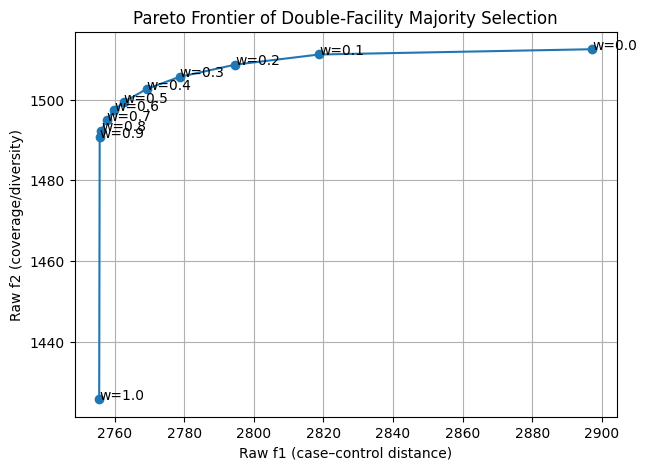

In [10]:
plt.figure(figsize=(7,5))
plt.plot(all_records["f1"], all_records["f2"], marker="o", linestyle="-")

for i,row in all_records.iterrows():
    plt.text(row["f1"], row["f2"], f"w={row['w']:.1f}")

plt.xlabel("Raw f1 (case–control distance)")
plt.ylabel("Raw f2 (coverage/diversity)")
plt.title("Pareto Frontier of Double-Facility Majority Selection")
plt.grid(True)
plt.show()

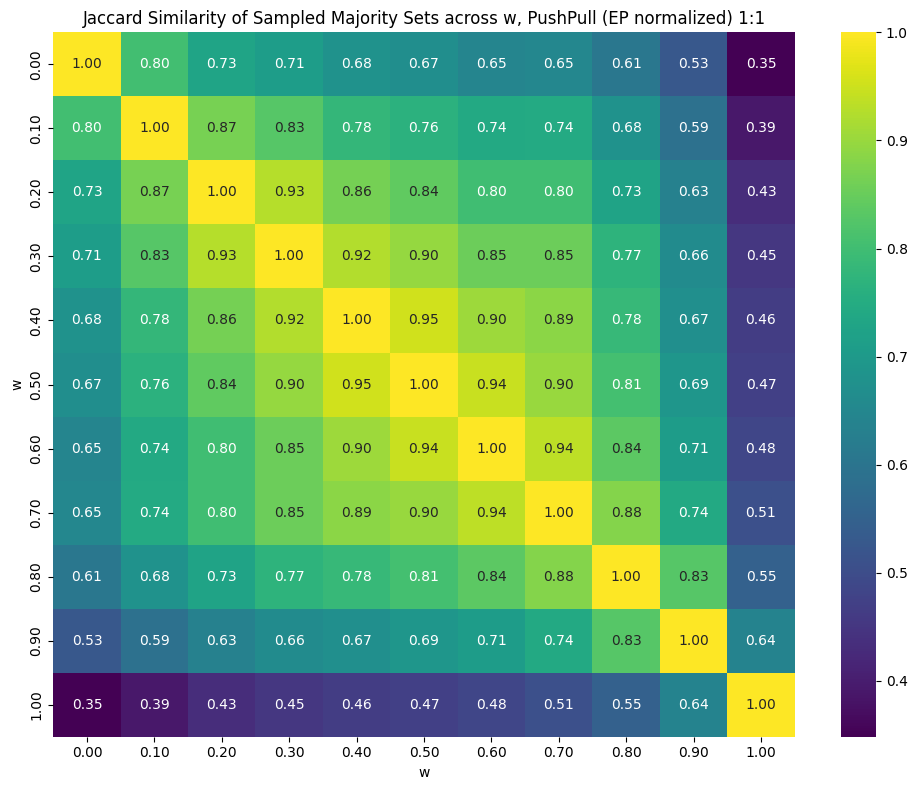

In [ ]:
id_col = "ENROLID"
majority_sets = {}
results_dir = "./w_sweep_results_doublefac_normalized_ratio1/"
w_values = np.linspace(0.0, 1.0, 11)

for w in w_values:
    path = f"{results_dir}/undersampled_w_{w:.2f}.csv"
    df = pd.read_csv(path)

    # Keep only majority samples
    maj_ids = set(df.loc[df[target_col] == 0, id_col].astype(int))

    majority_sets[w] = maj_ids
jac_mat = np.zeros((len(w_values), len(w_values)))

for i, wi in enumerate(w_values):
    A = majority_sets[wi]
    for j, wj in enumerate(w_values):
        B = majority_sets[wj]
        inter = len(A & B)
        union = len(A | B)
        jac_mat[i,j] = inter / union if union > 0 else np.nan
jac_df = pd.DataFrame(
    jac_mat,
    index=[f"{w:.2f}" for w in w_values],
    columns=[f"{w:.2f}" for w in w_values]
)
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(jac_df, annot=True, fmt=".2f", cmap="viridis")
plt.title("Jaccard Similarity of Sampled Majority Sets across w, PushPull (EP normalized) 1:1")
plt.xlabel("w")
plt.ylabel("w")
plt.tight_layout()
plt.show()



# Compute coverage of COST_COLUMNS in the selected majority subset


In [26]:
other_cols = [col for col in TRUE_NUM_COLUMNS if col not in COST_COLUMNS]
other_cols


['2017Q1_ckd_claims',
 '2017Q2_ckd_claims',
 '2017Q3_ckd_claims',
 '2017Q4_ckd_claims',
 'util_2017',
 'total_lab_tests',
 'nephrology_visit_count']

In [ ]:
analysis_cols = other_cols # COST_COLUMNS
string_cost_cols = [col for col in analysis_cols 
                    if train_pd[col].dtype == 'object' or train_pd[col].dtype.name == 'string']

print("\nString-based COST_COLUMNS:")
print(string_cost_cols)
binary_cost_cols = []
for col in analysis_cols:
    vals = pd.unique(train_pd[col].dropna())
    if len(vals) == 2 and set(vals).issubset({0, 1}):
        binary_cost_cols.append(col)

print("\nBinary COST_COLUMNS (0/1 only):")
print(binary_cost_cols)
numeric_non_binary_cost_cols = [
    col for col in analysis_cols
    if pd.api.types.is_numeric_dtype(train_pd[col])
    and col not in binary_cost_cols
]

print("\nFinal numeric non-binary COST_COLUMNS:")
print(numeric_non_binary_cost_cols)


String-based COST_COLUMNS:
[]

Binary COST_COLUMNS (0/1 only):
[]

Final numeric non-binary COST_COLUMNS:
['2017Q1_ckd_claims', '2017Q2_ckd_claims', '2017Q3_ckd_claims', '2017Q4_ckd_claims', 'util_2017', 'total_lab_tests', 'nephrology_visit_count']


## Prebalancing and M1


In [6]:
prebalance_threshold = 0
df_prebalanced = train_pd#[train_pd["annual_cost_2017"]>prebalance_threshold]
print(len(train_pd), len(df_prebalanced))

23479 23479


In [ ]:
import oct_stratifier
importlib.reload(oct_stratifier)
from oct_stratifier import train_stratifier_oct,train_stratifier_oct_tuned

target = "cost_stratum_2018"
df_prebalanced = train_pd
tune = False
best_params = {'max_depth': 9, 'minbucket': 100, 'cp': 1e-05}
# After your pre-balancing step:
if tune: 
    pipeline_results = train_stratifier_oct_tuned(
        df_prebalanced=df_prebalanced,
        stratification_cols=[col for col in feature_cols if col not in COST_COLUMNS],
        CAT_COLUMNS=CAT_COLUMNS,
        TRUE_NUM_COLUMNS=TRUE_NUM_COLUMNS,
        target=target
    )
else:
    pipeline_results = train_stratifier_oct(
        df_prebalanced=df_prebalanced,
        stratification_cols=[col for col in feature_cols if col not in COST_COLUMNS],
        CAT_COLUMNS=CAT_COLUMNS,
        TRUE_NUM_COLUMNS=TRUE_NUM_COLUMNS,
        target=target,
        best_params =best_params
    )
# Access results:
df_M1 = pipeline_results['df_with_leaves']
model = pipeline_results['model']
preprocessor = pipeline_results['preprocessor']
feature_names = pipeline_results['feature_names']

model

### Matching

In [ ]:
from balancing_functions.bilevel_sampler import BilevelResampler

import balancing_functions.optimal_match_lexicographic
importlib.reload(balancing_functions.optimal_match_lexicographic)


<module 'balancing_functions.optimal_match_lexicographic' from '/Users/cat2510/my_projects/balancing_functions/optimal_match_lexicographic.py'>

In [17]:
def create_doublefacility_undersampled_data(
    pipeline_results, 
    target_col, 
    undersampling_ratio=5.0,
    w_fixed=0.2,
    balance_tolerance=2.0,
    verbose=True
):
    """
    Replace BilevelResampler with DoubleFacilitySampler.
    Solve biobjective normalized facility-location at fixed w.

    Parameters
    ----------
    w_fixed : float (in [0,1])
        Fixed weight for f1–f2 normalized objective.
    """

    # ---------------------------------------------------
    # Create sampler
    # ---------------------------------------------------
    matcher = DoubleFacilitySampler(
        matching_method="ortools",
        random_state=42,
        binary_group=target_col,
        uid_col="ENROLID"
    )

    # ---------------------------------------------------
    # Extract dataset
    # ---------------------------------------------------
    df_with_leaves = pipeline_results['df_with_leaves']
    feature_cols = pipeline_results['stratification_cols']

    print(f"=== DOUBLE-FACILITY NORMALIZED UNDERSAMPLING ===")
    print(f"Original dataset: {len(df_with_leaves):,} samples")

    unique_leaves = df_with_leaves['leaf_assignment'].unique()
    print(f"Processing {len(unique_leaves)} OCT leaves...")

    undersampled_parts = []

    # ---------------------------------------------------
    # Iterate each OCT leaf
    # ---------------------------------------------------
    for leaf_id in sorted(unique_leaves):
        leaf_df = df_with_leaves[
            df_with_leaves['leaf_assignment'] == leaf_id
        ].copy()

        # Skip very small leaves
        if len(leaf_df) < 30:
            if verbose:
                print(f"Leaf {leaf_id}: Skipped (too small: {len(leaf_df)} samples)")
            continue

        # Distribution
        class_counts = leaf_df[target_col].value_counts()
        majority_class = class_counts.index[0]
        minority_class = class_counts.index[1]

        n_majority = class_counts[majority_class]
        n_minority = class_counts[minority_class]

        # Check balance tolerance
        if n_majority <= balance_tolerance * n_minority:
            if verbose:
                print(f"Leaf {leaf_id}: Already near-balanced, keeping as-is")
                print(f"  Counts: {n_majority} majority, {n_minority} minority")
            undersampled_parts.append(leaf_df)
            continue

        # Target majority count
        target_majority = n_minority * undersampling_ratio
        if target_majority >= n_majority:
            if verbose:
                print(f"Leaf {leaf_id}: target majority >= existing majority → keeping as-is")
            undersampled_parts.append(leaf_df)
            continue

        majority_df = leaf_df[leaf_df[target_col] == majority_class].copy()
        minority_df = leaf_df[leaf_df[target_col] == minority_class].copy()

        if verbose:
            print(f"\nLeaf {leaf_id}: majority {n_majority} → target {target_majority:.0f}, minority={n_minority}")

        # ---------------------------------------------------
        # Run the double-facility normalized solver
        # ---------------------------------------------------
        try:
            matched_result = matcher.biobjective_double_facility_wrapper(
                df_cases=minority_df,
                df_controls=majority_df,
                exclude_cols_matching=['leaf_assignment', 'cost_stratum'] + COST_COLUMNS,
                final_ratio=undersampling_ratio,
                w=w_fixed,
                top_k_case_ctrl=40,
                top_k_ctrl_ctrl=40,
                K_factor=10.0,
                stratified=False,    # no stratification unless you want it
                verbose=verbose
            )

            undersampled_parts.append(matched_result)

            if verbose:
                final_counts = matched_result[target_col].value_counts()
                print(f"  Result leaf {leaf_id}: {dict(final_counts)}")

        except Exception as e:
            if verbose:
                print(f"  Optimization failed in leaf {leaf_id}: {e}")
                print("  Keeping leaf as-is.")
            undersampled_parts.append(leaf_df)

    # ---------------------------------------------------
    # Combine final subsets
    # ---------------------------------------------------
    if undersampled_parts:
        final_result = pd.concat(undersampled_parts, ignore_index=True)

        print("\n=== FINAL RESULTS ===")
        print(f"Original:     {len(df_with_leaves):,}")
        print(f"Undersampled: {len(final_result):,}")
        print(f"Reduction:    {(1 - len(final_result)/len(df_with_leaves))*100:.1f}%")

        orig = df_with_leaves[target_col].value_counts()
        fin  = final_result[target_col].value_counts()
        print("Class distribution:")
        for cls in orig.index:
            print(f"  Class {cls}: {orig[cls]:,} → {fin.get(cls, 0):,}")

        return final_result
    else:
        print("Warning: No leaves processed successfully.")
        return pd.DataFrame()

undersampled_training_data = create_doublefacility_undersampled_data(
    pipeline_results=pipeline_results,
    target_col=target_col,
    undersampling_ratio=1,   # or 2,3,4
    w_fixed=0.2,
    verbose=True
)

print("Final training data size:", len(undersampled_training_data))


=== DOUBLE-FACILITY NORMALIZED UNDERSAMPLING ===
Original dataset: 23,479 samples
Processing 10 OCT leaves...

Leaf 3: majority 20556 → target 302, minority=302
>>> Distance computation will use 44 features
5 Categorical features (one-hot encoded): ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'lab_monitoring_intensity']
14 Numeric features (normalized): ['stage_2017', 'util_2017', '2017Q1_ckd_claims', '2017Q1_max_ckd_stage', '2017Q2_ckd_claims', '2017Q2_max_ckd_stage', '2017Q3_ckd_claims', '2017Q3_max_ckd_stage', '2017Q4_ckd_claims', '2017Q4_max_ckd_stage', 'total_lab_tests', 'nephrology_visit_count', 'cost_stratum_2018', 'predicted_cost_stratum']
25 Binary features (unchanged): ['has_Hypertension', 'has_Type_2_Diabetes', 'has_Anemia', 'has_Hyperlipidemia', 'has_Acute_Kidney_Failure', 'has_Hyperparathyroidism', 'has_Kidney_Transplant', 'has_Vitamin_D_Deficiency', 'has_Long-term_Drug_Therapy', 'has_Hypothyroidism', 'has_Sleep_Apnea', 'Antihyperlipidemic Drugs, NEC (THRCLS_53)', 'Cardiac,

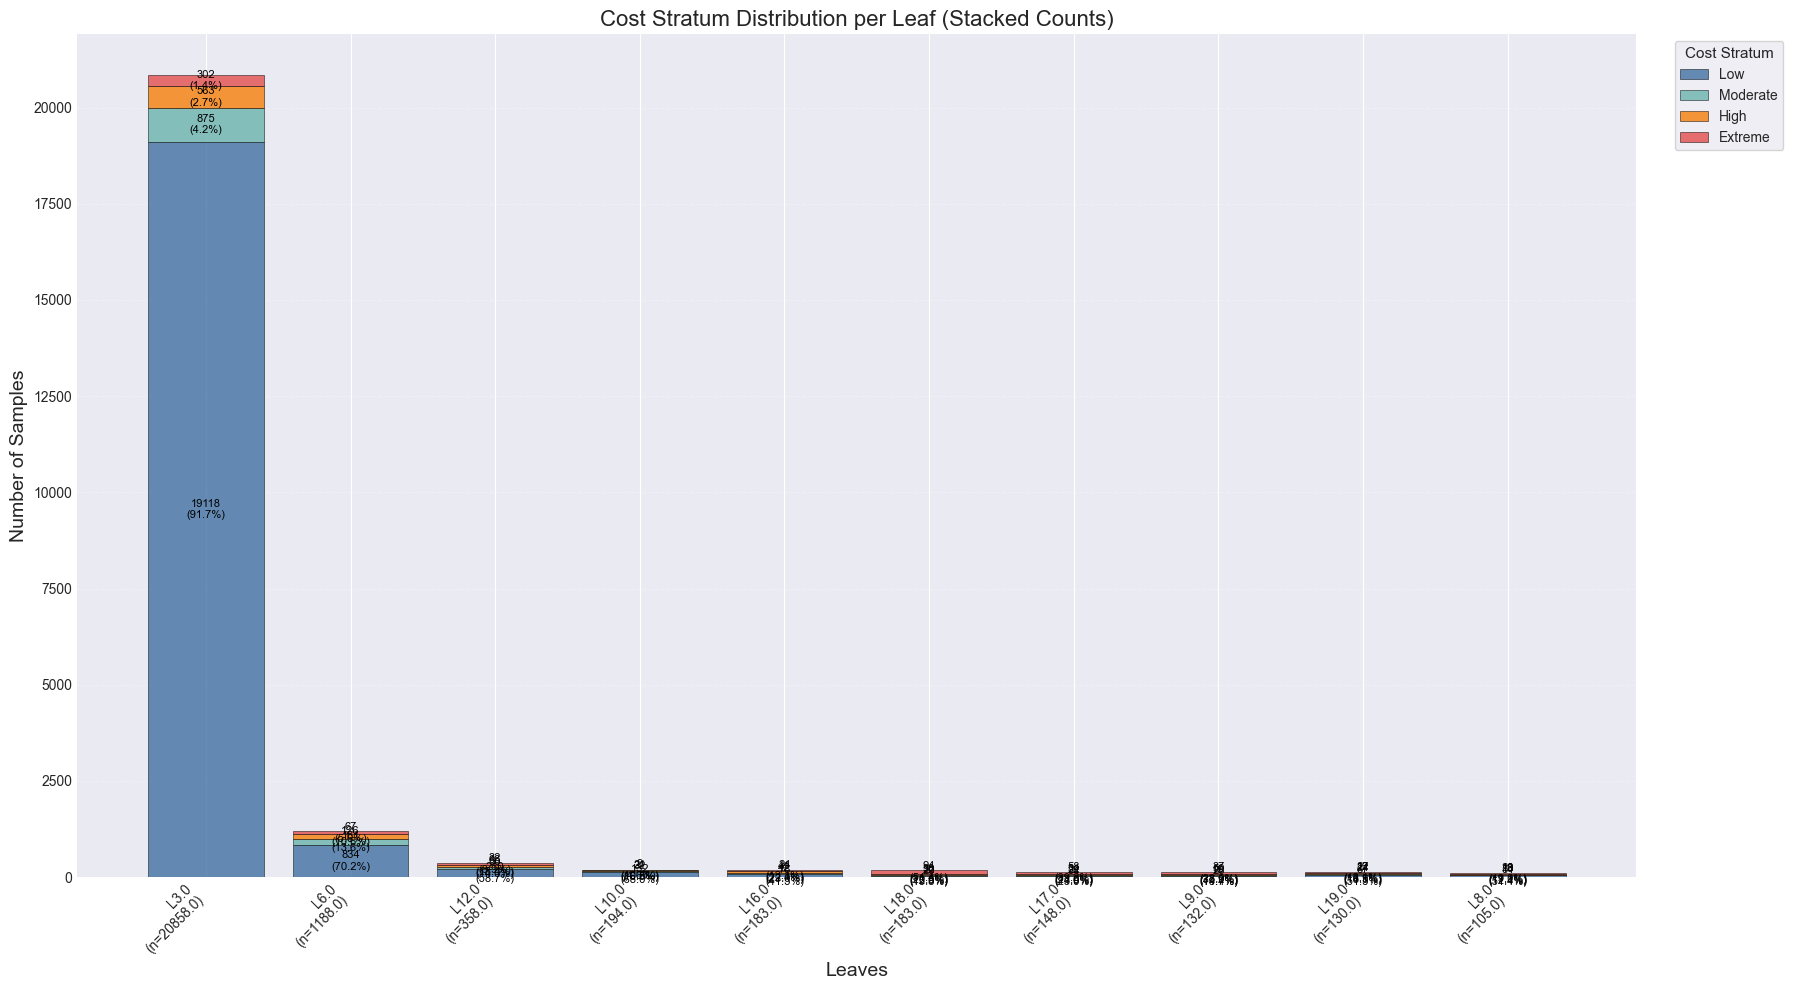


LEAF STRATUM SUMMARY
Overall class distribution across all leaves:
  Stratum 0 (Low): 20580 (87.7%)
  Stratum 1 (Moderate): 1260 (5.4%)
  Stratum 2 (High): 979 (4.2%)
  Stratum 3 (Extreme): 660 (2.8%)

Dominant stratum frequency among selected leaves:
  Stratum 0 (Low): 7 leaves (70.0%)
  Stratum 3 (Extreme): 2 leaves (20.0%)
  Stratum 2 (High): 1 leaves (10.0%)

Mean predicted vs actual rates (overall):
 Stratum    Label  Actual_Rate  Pred_Rate
       0      Low        0.877      0.980
       1 Moderate        0.054      0.000
       2     High        0.042      0.006
       3  Extreme        0.028      0.014


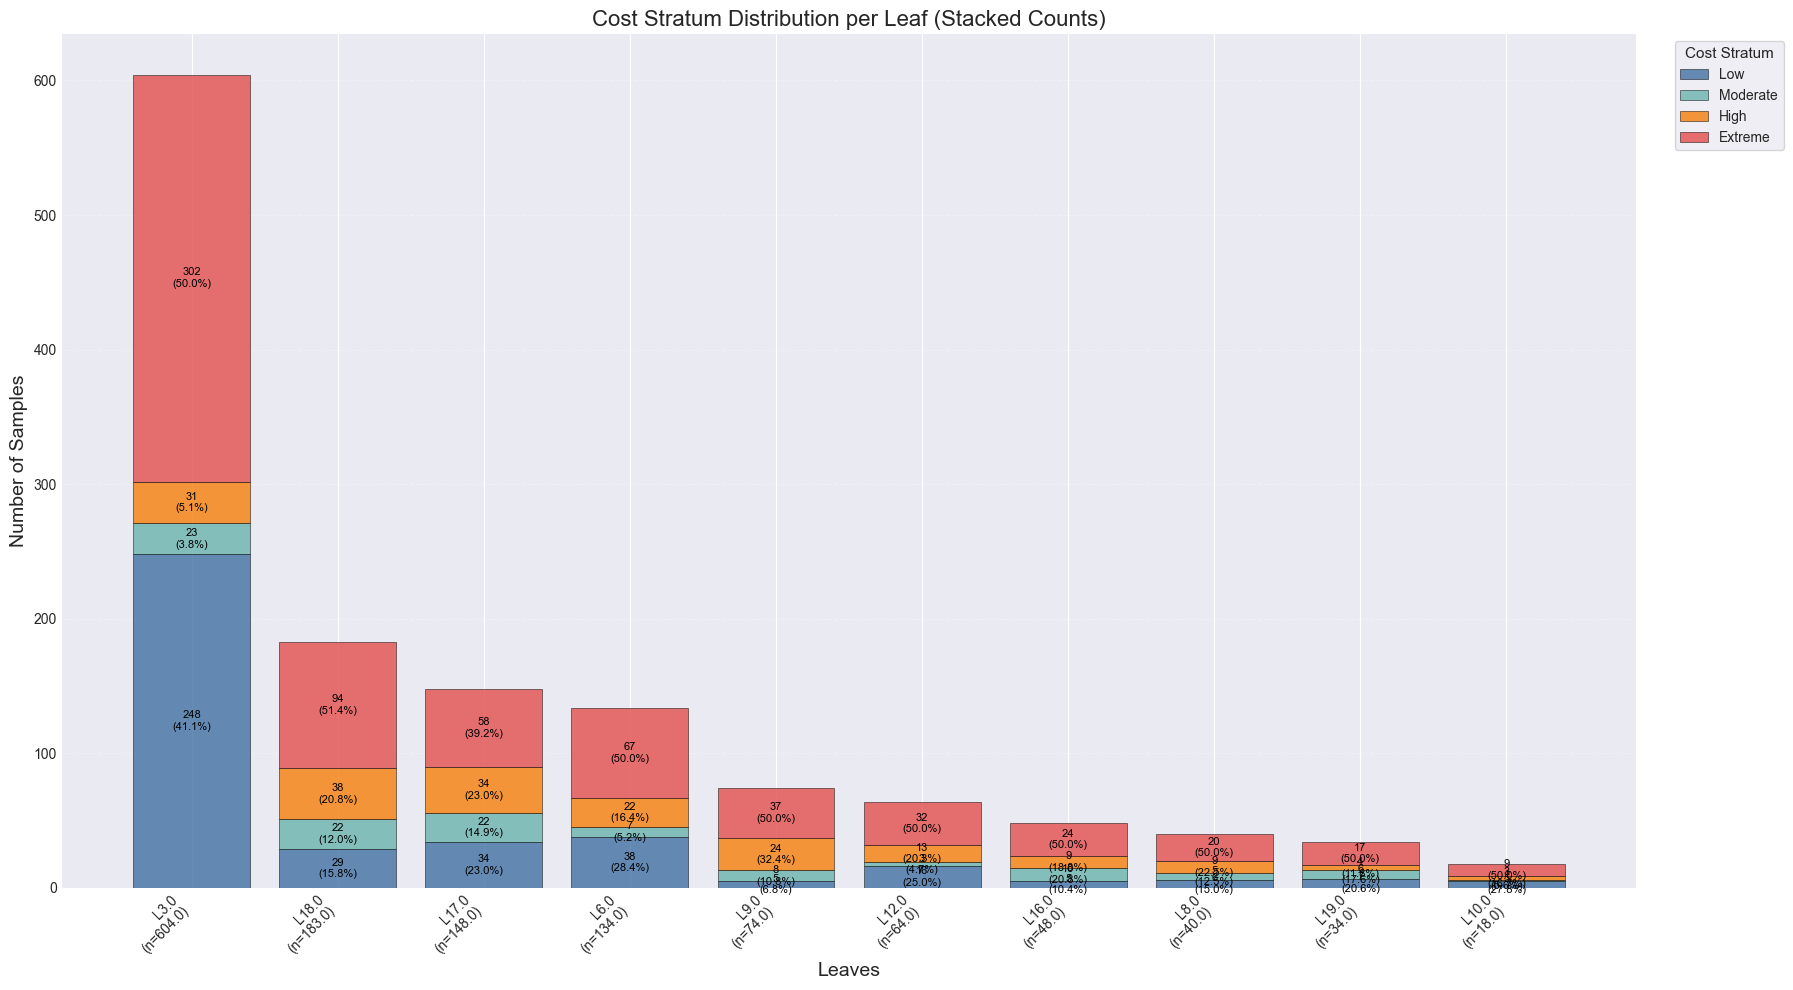


LEAF STRATUM SUMMARY
Overall class distribution across all leaves:
  Stratum 0 (Low): 393 (29.2%)
  Stratum 1 (Moderate): 107 (7.9%)
  Stratum 2 (High): 187 (13.9%)
  Stratum 3 (Extreme): 660 (49.0%)

Dominant stratum frequency among selected leaves:
  Stratum 3 (Extreme): 10 leaves (100.0%)

Mean predicted vs actual rates (overall):
 Stratum    Label  Actual_Rate  Pred_Rate
       0      Low        0.292      0.699
       1 Moderate        0.079      0.000
       2     High        0.139      0.055
       3  Extreme        0.490      0.246


In [18]:
import oct_leaf_analysis
importlib.reload(oct_leaf_analysis)
labels = {0: 'Low', 1: 'Moderate', 2: 'High', 3: 'Extreme'}
colors = {0: '#4C78A8', 1: '#72B7B2', 2: '#F58518', 3: '#E45756'}
leaf_stats_df = oct_leaf_analysis.visualize_leaf_cost_distributions_4class(
    df_M1,
    strata_labels=labels,
    strata_colors=colors
)

leaf_stats_df = oct_leaf_analysis.visualize_leaf_cost_distributions_4class(
    undersampled_training_data,
    strata_labels=labels,
    strata_colors=colors
)


# Model Comparisons

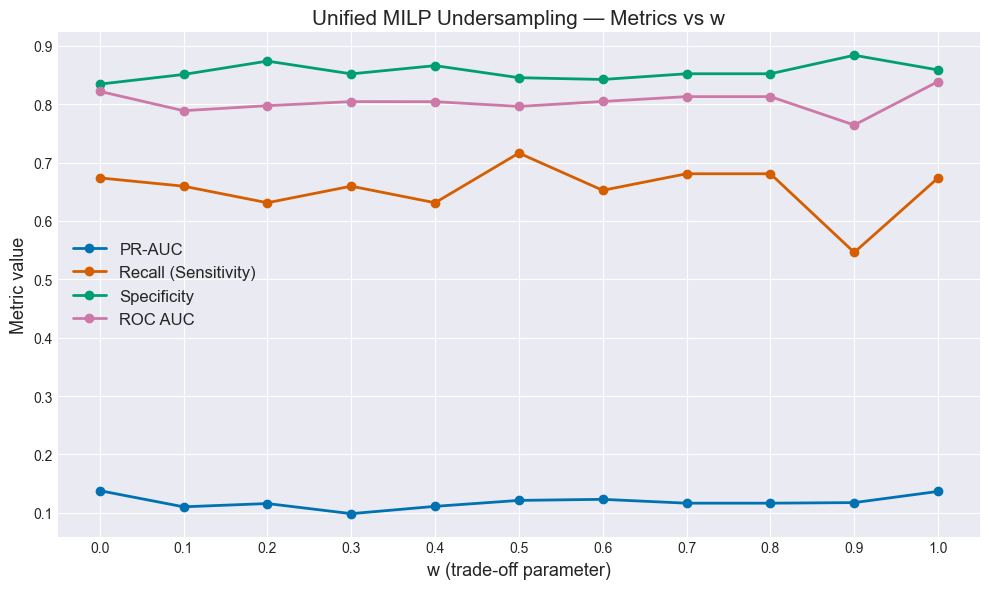

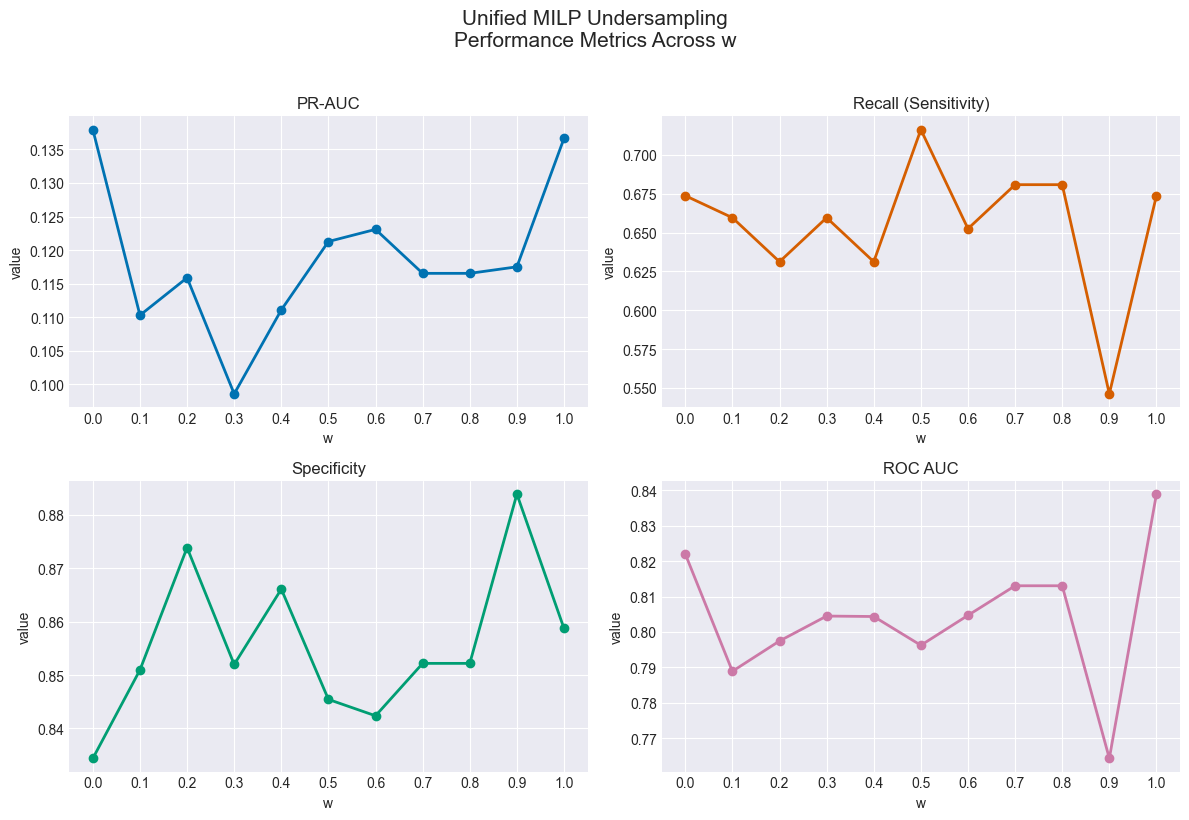

In [11]:
import re,os
import pickle

#results_dir = "./w_sweep_results_dispersion/"
# Regex to extract w value from filename "metrics_full_w_0.25.pkl"
pattern = re.compile(fr"metrics_full_w_([0-9.]+)\_seed{split_seed}.pkl")

records = []

# Load all pickle metric files
for fname in os.listdir(results_dir):
    m = pattern.match(fname)
    if not m:
        continue

    w = float(m.group(1))
    path = os.path.join(results_dir, fname)

    with open(path, "rb") as f:
        metrics = pickle.load(f)

    metrics = metrics.copy()      # avoid mutating original dict
    metrics["w"] = w

    # Remove leaf_metrics (big dataframe)
    if "leaf_metrics" in metrics:
        del metrics["leaf_metrics"]

    records.append(metrics)

# Create DataFrame sorted by w
df = pd.DataFrame(records).sort_values("w").reset_index(drop=True)
plt.style.use("seaborn-v0_8-darkgrid")

metrics_to_plot = ["pr_auc", "sensitivity", "specificity", "auc"]
titles = ["PR-AUC", "Recall (Sensitivity)", "Specificity", "ROC AUC"]
colors = ["#0072B2", "#D55E00", "#009E73", "#CC79A7"]

# ---------------------------
# Combined plot
# ---------------------------
plt.figure(figsize=(10, 6))
for metric, title, c in zip(metrics_to_plot, titles, colors):
    plt.plot(df["w"], df[metric], marker="o", linewidth=2, label=title, color=c)

plt.xlabel("w (trade-off parameter)", fontsize=13)
plt.ylabel("Metric value", fontsize=13)
plt.title("Unified MILP Undersampling — Metrics vs w", fontsize=15)
plt.legend(fontsize=12)
plt.xticks(df["w"])
plt.tight_layout()
plt.show()



# ---------------------------
# Separate subplot grid
# ---------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, metric, title, c in zip(axes, metrics_to_plot, titles, colors):
    ax.plot(df["w"], df[metric], marker="o", color=c, linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("w")
    ax.set_ylabel("value")
    ax.set_xticks(df["w"])
    ax.grid(True)

fig.suptitle("Unified MILP Undersampling\nPerformance Metrics Across w", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


# Vanilla OCT

In [15]:
import model_IAI
importlib.reload(model_IAI)
from model_IAI import evaluate_binary_oct, finetune_oct


In [ ]:

X_train = train_pd[feature_cols]
y_train = train_pd[target_col]
print(X_train.shape)

minbuckets_M2=[100,150,200]
cps_M2=[0.00001,5e-5, 0.0001,5e-3]
depths_M2=[5,7,9]
imbalanced_model, imbalanced_params, results_imbalanced ,preprocessor, feature_names = finetune_oct(
    X_train, y_train,X_val, y_val,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS,
    depths=depths_M2,
    minbuckets=minbuckets_M2,
    cps=cps_M2
)

print("Best params:", imbalanced_params)



In [16]:
print("Vanilla model: ", evaluate_binary_oct(imbalanced_model,X_test,y_test,preprocessor,feature_names,results_dir="vanilla_oct" ))
imbalanced_model

Test dataset for OCT application: 5,032 samples
✓ Predictions completed
✓ Saved OCT predictions to: vanilla_oct/predictions/oct_predictions.csv
✓ Saved split table (2 splits) to: vanilla_oct/oct_tree_splits.csv
AUC score: 0.574
PR-AUC (Average Precision): 0.078
Sensitivity (Recall): 0.128
Specificity: 0.994
Balanced (G-mean) recall: 0.454
Balanced (G-mean) specificity: 0.651
Sensitivity (default): 0.128
Specificity (default): 0.994
Number of leaves: 3
Vanilla model:  {'auc': 0.5735596282649706, 'pr_auc': np.float64(0.07816218617803225), 'f1_threshold': np.float64(0.57), 'optimal_f1': np.float64(0.19354838706009364), 'sensitivity_f1': np.float64(0.1276595744680851), 'specificity_f1': np.float64(0.9944796565119608), 'sensitivity_default': np.float64(0.1276595744680851), 'specificity_default': np.float64(0.9944796565119608), 'balanced_threshold_gmean': np.float64(0.028058085158749694), 'balanced_recall_gmean': np.float64(0.45390070921985815), 'balanced_specificity_gmean': np.float64(0.651

Fitted OptimalTreeClassifier:
  1) Split: quarterly_cv_2017 < 0.3913
    2) Split: 2017Q4_ckd_cost < 2.587
      3) Predict: 0 (97.90%), [14835,318], 15153 points, error 0.02099
      4) Predict: 1 (57.00%), [86,114], 200 points, error 0.43
    5) Predict: 0 (97.19%), [7898,228], 8126 points, error 0.02806

In [18]:
import model_IAI
importlib.reload(model_IAI)
from model_IAI import evaluate_binary_oct, finetune_oct
from imblearn.under_sampling import RandomUnderSampler
X = train_pd.drop(columns=[target_col])
y = train_pd[target_col]

ratio = 1.0   # majority should be 2x minority

minority_count = y.value_counts()[1]
target_majority = int(minority_count * ratio)

rus = RandomUnderSampler(
    sampling_strategy={0: target_majority, 1: minority_count},
    random_state=123
)

X_res, y_res = rus.fit_resample(X, y)

undersampled_rus = pd.concat([X_res, y_res], axis=1)
print(undersampled_rus['cost_stratum_2018'].value_counts())

print(X_res.shape)
rus_model, rus_params, results_rus,preprocessor, feature_names = finetune_oct(
    X_res[feature_cols], y_res,X_val, y_val,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS,
    depths=depths_M2,
    minbuckets=minbuckets_M2,
    cps=cps_M2
)

print("Best params:", rus_params)
print(results_rus)
rus_model


evaluate_binary_oct(rus_model,X_test,y_test,preprocessor,feature_names,results_dir="random_undersample_oct")

cost_stratum_2018
3    660
0    589
1     38
2     33
Name: count, dtype: int64
(1320, 95)
→ Building preprocessor:
   • OneHotEncoder on: ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
   • StandardScaler on: ['2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_direct_ckd_cost', '2017Q4_procedure_ckd_cost', '2017Q4_comorbidity_ckd_cost', 'ckd_cost_trend_2017', 'ckd_cost_volatility_2017', 'ckd_cost_deriv_Q1_Q2_2017', 'ckd_cost_deriv_Q2_Q3_2017', 'ckd_cost_deriv_Q3_Q4_2017', 'avg_quarterly_derivative_2017', 'quarterly_std_2017', 'quarterly_skewness_201

/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Best params: (5, 150, 0.005)
    depth  minbucket       cp  precision    recall        f1
31      9        150  0.00500   0.107180  0.725352  0.186763
7       5        150  0.00500   0.107180  0.725352  0.186763
19      7        150  0.00500   0.107180  0.725352  0.186763
0       5        100  0.00001   0.095819  0.774648  0.170543
1       5        100  0.00005   0.095819  0.774648  0.170543
2       5        100  0.00010   0.095819  0.774648  0.170543
3       5        100  0.00500   0.095819  0.774648  0.170543
26      9        100  0.00010   0.085950  0.732394  0.153846
25      9        100  0.00005   0.085950  0.732394  0.153846
24      9        100  0.00001   0.085950  0.732394  0.153846
12      7        100  0.00001   0.085950  0.732394  0.153846
13      7        100  0.00005   0.085950  0.732394  0.153846
14      7        100  0.00010   0.085950  0.732394  0.153846
27      9        100  0.00500   0.082362  0.795775  0.149273
15      7        100  0.00500   0.082362  0.795775  0.14

/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


✓ Predictions completed
✓ Saved OCT predictions to: random_undersample_oct/predictions/oct_predictions.csv
✓ Saved split table (3 splits) to: random_undersample_oct/oct_tree_splits.csv
AUC score: 0.828
PR-AUC (Average Precision): 0.101
Sensitivity (Recall): 0.496
Specificity: 0.899
Balanced (G-mean) recall: 0.759
Balanced (G-mean) specificity: 0.826
Sensitivity (default): 0.759
Specificity (default): 0.826
Number of leaves: 4


{'auc': 0.8281914531104315,
 'pr_auc': np.float64(0.10140577249241856),
 'f1_threshold': np.float64(0.8209606986899564),
 'optimal_f1': np.float64(0.19801980194826596),
 'sensitivity_f1': np.float64(0.49645390070921985),
 'specificity_f1': np.float64(0.8985892455530566),
 'sensitivity_default': np.float64(0.7588652482269503),
 'specificity_default': np.float64(0.8264158658760989),
 'balanced_threshold_gmean': np.float64(0.7483443708609272),
 'balanced_recall_gmean': np.float64(0.7588652482269503),
 'balanced_specificity_gmean': np.float64(0.8264158658760989),
 'balanced_threshold_minside': np.float64(0.7483443708609272),
 'balanced_recall_minside': np.float64(0.7588652482269503),
 'balanced_specificity_minside': np.float64(0.8264158658760989)}

### Non OCT models

In [ ]:
def fit_and_evaluate_models(X_train, y_train, X_test, y_test, categorical_cols, numeric_cols, ):
    # ---- Logistic Regression ----
    log_pipeline = model_pipeline.get_logistic_pipeline(
        df=X_train,
        categorical_cols=categorical_cols,
        numeric_cols=numeric_cols,
        C=0.1,
        max_iter=1000,
    )
    log_pipeline.fit(X_train, y_train)

    log_metrics = model_pipeline.evaluate_model_auc(log_pipeline, X_test, y_test)
    log_metrics.update({"model": "logistic", "w": w})
    # ---- Random Forest ----
    rf_pipeline = model_pipeline.get_random_forest_pipeline(
        df=X_train_undersampled,
        categorical_cols=CAT_COLUMNS,
        numeric_cols=TRUE_NUM_COLUMNS,
    )
    rf_pipeline.fit(X_train_undersampled, y_train_undersampled)

    rf_metrics = model_pipeline.evaluate_model_auc(rf_pipeline, X_test, y_test)
    rf_metrics.update({"model": "rf", "w": w})
    
    # ---- Gradient Boosting ----
    gb_pipeline = model_pipeline.get_histgb_pipeline(
        df=X_train_undersampled,
        categorical_cols=CAT_COLUMNS,
        numeric_cols=TRUE_NUM_COLUMNS,
        balance_classes=True,
    )
    gb_pipeline.fit(X_train_undersampled, y_train_undersampled)

    gb_metrics = model_pipeline.evaluate_model_auc(gb_pipeline, X_test, y_test)
    gb_metrics.update({"model": "histgb", "w": w})
    return log_metrics, rf_metrics, gb_metrics



In [ ]:
from model_pipeline import evaluate_model_auc

# Filter test data to only include low 2017 cost subgroup
low_cost_threshold = test_pd['annual_cost_2017'].quantile(0.9)
test_pd_low_cost = test_pd[test_pd['annual_cost_2017'] <= low_cost_threshold].copy()
X_test_low_cost = test_pd_low_cost[feature_cols]
y_test_low_cost = test_pd_low_cost[target_col]

print(f"Filtered test data: {len(test_pd_low_cost)} samples (out of {len(test_pd)} total)")
print(f"Low cost threshold: ${low_cost_threshold:,.2f}")
print(f"Target distribution in low cost subgroup:")
print(y_test_low_cost.value_counts(normalize=True))
#################################
results_dir = "./w_sweep_results_pushpull_ratio2/" #allmajority
w_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
w_values = [-1.0]
records = []
for w in w_values:
    if w == -1.0:
        undersampled_training_data = train_pd
    else:
        save_path = f"{results_dir}/undersampled_w_{w:.2f}.csv"
        undersampled_training_data = pd.read_csv(save_path)
    X_train_undersampled = undersampled_training_data[feature_cols]
    y_train_undersampled = undersampled_training_data[target_col]
    log_metrics, rf_metrics, gb_metrics = fit_and_evaluate_models(X_train_undersampled, y_train_undersampled, X_test, y_test, CAT_COLUMNS, TRUE_NUM_COLUMNS)
    records.append(log_metrics)

    records.append(rf_metrics)

    records.append(gb_metrics)


df_results = pd.DataFrame(records)
df_results.to_csv("vanilla_non_oct_results.csv", index=False)



In [ ]:

metrics = ["auc", "pr_auc", "specificity", "recall", "f1"]
baseline_df = pd.read_csv("vanilla_non_oct_results.csv")
df_results = pd.read_csv("nonoct_sweep_results_pushpull_ratio2.csv")
baseline_per_model = baseline_df.groupby("model").mean(numeric_only=True)
import seaborn as sns
import matplotlib.pyplot as plt

for m in metrics:
    plt.figure(figsize=(7,5))

    # Sweep curves
    sns.lineplot(
        data=df_results,
        x="w",
        y=m,
        hue="model",
        marker="o",
        linewidth=2
    )

    # Baseline horizontal lines (one per model)
    for model_name, row in baseline_per_model.iterrows():
        plt.axhline(
            y=row[m],
            linestyle="--",
            linewidth=1.5,
            alpha=0.8,
        )

        # Annotate a little label on the line
        plt.text(
            x=df_results["w"].min(),
            y=row[m],
            s=f"{model_name} baseline",
            va="bottom",
            fontsize=9,
            alpha=0.7
        )

    plt.title(f"{m.upper()} vs w")
    plt.xlabel("w")
    plt.ylabel(m.upper())
    plt.grid(True, alpha=0.3)
    plt.show()

